# DINOv3 Feature Visualization

## Setup

In [110]:
import subprocess, os, sys

UV = '/root/.local/bin/uv'
INSTALL_CMD = [UV, 'pip', 'install', '--system'] if os.path.exists(UV) else [sys.executable, '-m', 'pip', 'install']

subprocess.run([
    *INSTALL_CMD,
    'torch', 'torchvision',
    'opencv-python-headless',
    'matplotlib',
    'numpy',
    'Pillow',
    'tqdm',
    'scikit-learn',
    'requests',
    'transformers',
], check=True)

FileNotFoundError: [Errno 2] No such file or directory: '/root/.local/bin/uv'

In [121]:
import time, os

VIDEO_PATH = './scratch_3.mp4'
RUN_DIR    = f'./runs/p68/{int(time.time())}'
FRAMES_DIR = f'{RUN_DIR}/frames'
OUTPUT_DIR = f'{RUN_DIR}/output'

In [122]:
import subprocess, os
import cv2
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image
from tqdm import tqdm
from sklearn.decomposition import PCA
from transformers import AutoImageProcessor, AutoModel

DEVICE = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

Using device: mps


## 1. Extract Frames

In [123]:
import requests, os
import cv2
from PIL import Image

os.makedirs(FRAMES_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

VIDEO_URL = 'https://www.dropbox.com/scl/fi/b3bdak9jdrbz1j063gaam/scratch_3.mp4?rlkey=qvrfed1dpwqz4g0rprenebips&dl=1'

if not os.path.exists(VIDEO_PATH):
    print('Downloading video...')
    r = requests.get(VIDEO_URL, stream=True)
    r.raise_for_status()
    with open(VIDEO_PATH, 'wb') as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
    print('Done.')
else:
    print('Already downloaded.')

IMG_SIZE = 1120

def center_crop_resize(frame_bgr, size=IMG_SIZE):
    img = Image.fromarray(cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB))
    w, h = img.size
    s = min(w, h)
    img = img.crop(((w - s) // 2, (h - s) // 2, (w + s) // 2, (h + s) // 2))
    return img.resize((size, size), Image.LANCZOS)

cap = cv2.VideoCapture(VIDEO_PATH)
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps   = cap.get(cv2.CAP_PROP_FPS)
print(f'{total} frames @ {fps:.1f} fps')

frame_paths = []
saved = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break
    img = center_crop_resize(frame)
    path = f'{FRAMES_DIR}/{saved:04d}.png'
    img.save(path)
    frame_paths.append(path)
    saved += 1
cap.release()
print(f'Saved {saved} frames to {RUN_DIR}')

Already downloaded.
275 frames @ 30.0 fps
Saved 275 frames to ./runs/p68/1776615832


## 2. Load DINOv3

In [124]:
MODEL_NAME = 'facebook/dinov3-vitb16-pretrain-lvd1689m'
image_processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE).eval()

PATCH_SIZE = 16
N_PATCHES  = IMG_SIZE // PATCH_SIZE  # 70
print(f'Patch grid: {N_PATCHES}x{N_PATCHES}')

def get_features(img_path):
    img = Image.open(img_path).convert('RGB')
    inputs = image_processor(
        images=img,
        return_tensors='pt',
        do_resize=False,
        do_center_crop=False,
    )
    x = inputs['pixel_values'].to(DEVICE)
    with torch.no_grad():
        outputs = model(pixel_values=x, interpolate_pos_encoding=True)
    num_register_tokens = getattr(model.config, 'num_register_tokens', 0)
    patch_tokens = outputs.last_hidden_state[:, 1 + num_register_tokens:, :]
    expected_tokens = N_PATCHES * N_PATCHES
    if patch_tokens.shape[1] != expected_tokens:
        raise ValueError(f'Expected {expected_tokens} patch tokens, got {patch_tokens.shape[1]}')
    return patch_tokens.squeeze(0)  # (N, D)

Using cache found in /Users/pranav/.cache/torch/hub/facebookresearch_dinov2_main


KeyboardInterrupt: 

## 3. Feature Similarity (query point -> heatmap)

Query patch (7, 17), flat index 276


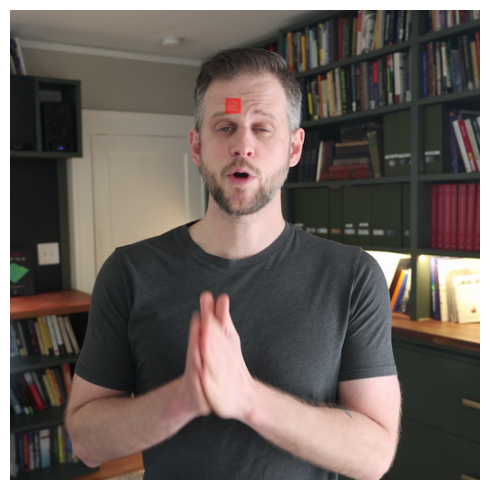

In [120]:
QUERY_X = 250
QUERY_Y = 100
QUERY_FRAME_IDX = 150

qr = QUERY_Y // PATCH_SIZE
qc = QUERY_X // PATCH_SIZE
q_idx = qr * N_PATCHES + qc
print(f'Query patch ({qr}, {qc}), flat index {q_idx}')

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(Image.open(frame_paths[QUERY_FRAME_IDX]))
ax.add_patch(plt.Rectangle((qc*PATCH_SIZE, qr*PATCH_SIZE), PATCH_SIZE, PATCH_SIZE,
                             linewidth=2, edgecolor='red', facecolor='red', alpha=0.4))
ax.axis('off')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/query_location.png', dpi=150)
plt.show()

In [116]:
q_feats = get_features(frame_paths[QUERY_FRAME_IDX])
q_vec   = F.normalize(q_feats[q_idx].unsqueeze(0), dim=-1)

SIM_DIR = f'{OUTPUT_DIR}/similarity'
os.makedirs(SIM_DIR, exist_ok=True)

for fi, fpath in enumerate(tqdm(frame_paths)):
    feats    = F.normalize(get_features(fpath), dim=-1)
    sim      = (feats @ q_vec.T).squeeze(-1).cpu().numpy()
    sim_img  = np.kron(sim.reshape(N_PATCHES, N_PATCHES), np.ones((PATCH_SIZE, PATCH_SIZE)))
    sim_norm = (sim_img - sim_img.min()) / (sim_img.max() - sim_img.min() + 1e-8)
    frame_np = np.array(Image.open(fpath))
    heat     = (cm.inferno(sim_img)[:, :, :3] * 255).astype(np.uint8)
    # mark query patch on frame
    frame_marked = frame_np.copy()
    if fi == 0:
        cv2.rectangle(frame_marked, (qc*PATCH_SIZE, qr*PATCH_SIZE),
                      ((qc+1)*PATCH_SIZE, (qr+1)*PATCH_SIZE), (255,0,0), 2)
    side_by_side = np.concatenate([frame_marked, heat], axis=1)
    Image.fromarray(side_by_side).save(f'{SIM_DIR}/{fi:04d}.png')

subprocess.run([
    'ffmpeg', '-y', '-framerate', str(fps),
    '-i', f'{SIM_DIR}/%04d.png',
    '-c:v', 'libx264', '-pix_fmt', 'yuv420p',
    f'{OUTPUT_DIR}/similarity.mp4'
], check=True)
print('Done: similarity.mp4')

100%|██████████| 275/275 [02:24<00:00,  1.90it/s]
ffmpeg version 8.1 Copyright (c) 2000-2026 the FFmpeg developers
  built with Apple clang version 17.0.0 (clang-1700.6.4.2)
  configuration: --prefix=/opt/homebrew/Cellar/ffmpeg/8.1 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags= --enable-ffplay --enable-gpl --enable-libsvtav1 --enable-libopus --enable-libx264 --enable-libmp3lame --enable-libdav1d --enable-libvpx --enable-libx265 --enable-openssl --enable-videotoolbox --enable-audiotoolbox --enable-neon
  libavutil      60. 26.100 / 60. 26.100
  libavcodec     62. 28.100 / 62. 28.100
  libavformat    62. 12.100 / 62. 12.100
  libavdevice    62.  3.100 / 62.  3.100
  libavfilter    11. 14.100 / 11. 14.100
  libswscale      9.  5.100 /  9.  5.100
  libswresample   6.  3.100 /  6.  3.100
Input #0, image2, from './runs/p68/1776608363/output/similarity/%04d.png':
  Duration: 00:00:09.18, start: 0.000000, bitrate: N/A
  Stream #0:0: Video: png, rg

Done: similarity.mp4


[out#0/mp4 @ 0x7b6c20240] video:1300KiB audio:0KiB subtitle:0KiB other streams:0KiB global headers:0KiB muxing overhead: 0.313267%
frame=  275 fps= 74 q=-1.0 Lsize=    1304KiB time=00:00:09.10 bitrate=1173.0kbits/s speed=2.45x elapsed=0:00:03.72    
[libx264 @ 0x7b6c1ca80] frame I:2     Avg QP:19.60  size: 38476
[libx264 @ 0x7b6c1ca80] frame P:69    Avg QP:22.83  size:  9651
[libx264 @ 0x7b6c1ca80] frame B:204   Avg QP:26.07  size:  2882
[libx264 @ 0x7b6c1ca80] consecutive B-frames:  1.1%  0.0%  0.0% 98.9%
[libx264 @ 0x7b6c1ca80] mb I  I16..4: 21.9% 40.4% 37.7%
[libx264 @ 0x7b6c1ca80] mb P  I16..4:  6.8%  7.9%  5.7%  P16..4: 25.6%  9.4%  4.7%  0.0%  0.0%    skip:39.9%
[libx264 @ 0x7b6c1ca80] mb B  I16..4:  1.8%  1.4%  1.0%  B16..8: 24.4%  4.1%  0.8%  direct: 1.8%  skip:64.7%  L0:44.1% L1:48.7% BI: 7.2%
[libx264 @ 0x7b6c1ca80] 8x8 transform intra:36.9% inter:74.3%
[libx264 @ 0x7b6c1ca80] coded y,uvDC,uvAC intra: 33.5% 82.6% 56.7% inter: 9.2% 10.4% 1.3%
[libx264 @ 0x7b6c1ca80] i16 v,h,dc

## 4. PCA Visualization

In [117]:
all_feats = np.concatenate([
    get_features(fpath).cpu().numpy()
    for fpath in tqdm(frame_paths[::3][:60], desc='Collecting features')
], axis=0)
print(f'Feature matrix: {all_feats.shape}')

pca = PCA(n_components=3)
pca.fit(all_feats)
print(f'Explained variance: {pca.explained_variance_ratio_}')

Feature matrix: (82140, 768)
Explained variance: [0.15410616 0.08321018 0.05817717]


In [118]:
PCA_DIR = f'{OUTPUT_DIR}/pca'
os.makedirs(PCA_DIR, exist_ok=True)

for fi, fpath in enumerate(tqdm(frame_paths, desc='PCA frames')):
    feats = get_features(fpath).cpu().numpy()
    proj  = pca.transform(feats)
    proj  = (proj - proj.min(0)) / (proj.max(0) - proj.min(0) + 1e-8)
    pca_map = np.kron(proj.reshape(N_PATCHES, N_PATCHES, 3), np.ones((PATCH_SIZE, PATCH_SIZE, 1)))
    pca_img = (pca_map * 255).astype(np.uint8)
    frame_np = np.array(Image.open(fpath))
    Image.fromarray(np.concatenate([frame_np, pca_img], axis=1)).save(f'{PCA_DIR}/{fi:04d}.png')

subprocess.run([
    'ffmpeg', '-y', '-framerate', str(fps),
    '-i', f'{PCA_DIR}/%04d.png',
    '-c:v', 'libx264', '-pix_fmt', 'yuv420p',
    f'{OUTPUT_DIR}/pca.mp4'
], check=True)
print('Done: pca.mp4')

PCA frames: 100%|██████████| 275/275 [02:17<00:00,  2.00it/s]
ffmpeg version 8.1 Copyright (c) 2000-2026 the FFmpeg developers
  built with Apple clang version 17.0.0 (clang-1700.6.4.2)
  configuration: --prefix=/opt/homebrew/Cellar/ffmpeg/8.1 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags= --enable-ffplay --enable-gpl --enable-libsvtav1 --enable-libopus --enable-libx264 --enable-libmp3lame --enable-libdav1d --enable-libvpx --enable-libx265 --enable-openssl --enable-videotoolbox --enable-audiotoolbox --enable-neon
  libavutil      60. 26.100 / 60. 26.100
  libavcodec     62. 28.100 / 62. 28.100
  libavformat    62. 12.100 / 62. 12.100
  libavdevice    62.  3.100 / 62.  3.100
  libavfilter    11. 14.100 / 11. 14.100
  libswscale      9.  5.100 /  9.  5.100
  libswresample   6.  3.100 /  6.  3.100
Input #0, image2, from './runs/p68/1776608363/output/pca/%04d.png':
  Duration: 00:00:09.18, start: 0.000000, bitrate: N/A
  Stream #0:0: Video: pn

Done: pca.mp4


[out#0/mp4 @ 0xaeec2c240] video:1657KiB audio:0KiB subtitle:0KiB other streams:0KiB global headers:0KiB muxing overhead: 0.245860%
frame=  275 fps= 79 q=-1.0 Lsize=    1661KiB time=00:00:09.10 bitrate=1493.6kbits/s speed=2.62x elapsed=0:00:03.47    
[libx264 @ 0xaef018a80] frame I:2     Avg QP:22.15  size: 48671
[libx264 @ 0xaef018a80] frame P:69    Avg QP:24.24  size: 12481
[libx264 @ 0xaef018a80] frame B:204   Avg QP:27.57  size:  3614
[libx264 @ 0xaef018a80] consecutive B-frames:  1.1%  0.0%  0.0% 98.9%
[libx264 @ 0xaef018a80] mb I  I16..4: 22.6% 24.0% 53.4%
[libx264 @ 0xaef018a80] mb P  I16..4:  9.0%  7.8%  9.0%  P16..4: 34.1% 10.3%  5.6%  0.0%  0.0%    skip:24.3%
[libx264 @ 0xaef018a80] mb B  I16..4:  2.4%  2.0%  1.4%  B16..8: 26.9%  4.0%  0.6%  direct: 3.6%  skip:59.0%  L0:45.0% L1:47.5% BI: 7.5%
[libx264 @ 0xaef018a80] 8x8 transform intra:31.5% inter:76.4%
[libx264 @ 0xaef018a80] coded y,uvDC,uvAC intra: 36.2% 91.5% 67.2% inter: 12.8% 20.4% 2.3%
[libx264 @ 0xaef018a80] i16 v,h,d

## 5. Preview

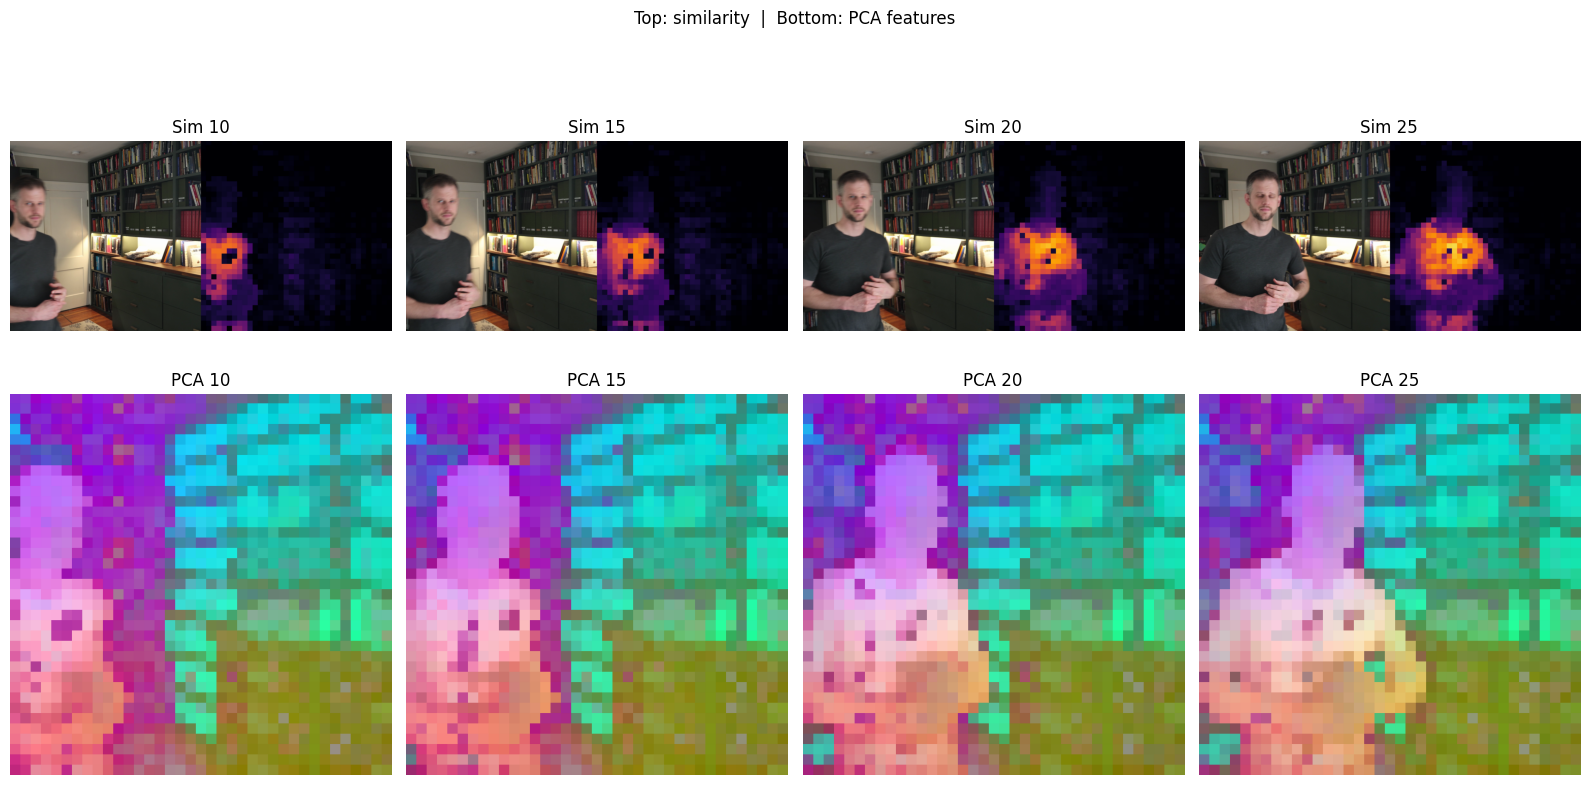

In [119]:
idxs = [10, 15, 20, 25]
fig, axes = plt.subplots(2, len(idxs), figsize=(4*len(idxs), 8))

for col, i in enumerate(idxs):
    sim_f = Image.open(f'{SIM_DIR}/{i:04d}.png')
    pca_f = Image.open(f'{PCA_DIR}/{i:04d}.png')
    w = pca_f.width // 2
    axes[0, col].imshow(sim_f); axes[0, col].axis('off'); axes[0, col].set_title(f'Sim {i}')
    axes[1, col].imshow(pca_f.crop((w, 0, pca_f.width, pca_f.height)))
    axes[1, col].axis('off'); axes[1, col].set_title(f'PCA {i}')

plt.suptitle('Top: similarity  |  Bottom: PCA features')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/preview.png', dpi=150)
plt.show()